# 1. Define Device

In [3]:
import gdstk
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
import math
import re
import os


# ===================================================================
# 层定义
# ===================================================================
LAYER_SD = 0       # Source/Drain - 源漏层
LAYER_SG = 1       # Screen Gate - 屏蔽门层
LAYER_BG = 2        # Barrier Gate - 势垒门层
LAYER_PG = 3        # Plunger Gate - 柱栅层
LAYER_LABEL = 100   # 标签层

# 解决中文显示问题
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial']
plt.rcParams['axes.unicode_minus'] = False


def plot_gds(cell, title="量子点器件布局"):
    """
    可视化GDS布局
    
    Parameters:
    -----------
    cell : gdstk.Cell
        GDS单元
    title : str
        图表标题
    """
    fig, ax = plt.subplots(figsize=(16, 12))
    ax.set_title(title, fontsize=18)
    
    # 层颜色配置 - 匹配图片中的颜色
    layer_config = {
        0: {'color': '#87CEEB', 'alpha': 0.6, 'label': 'S/D (L0) - 源漏', 'zorder': 2},
        1: {'color': '#D3D3D3', 'alpha': 0.5, 'label': 'SG (L1) - 屏蔽门', 'hatch': '///', 'zorder': 1},
        2: {'color': '#FF69B4', 'alpha': 0.9, 'label': 'BG (L2) - 势垒门', 'zorder': 3},
        3: {'color': '#9370DB', 'alpha': 0.9, 'label': 'PG (L3) - 柱栅', 'zorder': 4}
    }
    
    drawn_labels = set()
    
    # 按zorder排序绘制
    sorted_layers = [1, 0, 2, 3]
    
    for layer in sorted_layers:
        polygons = cell.get_polygons(layer=layer, datatype=0)
        if not polygons:
            continue
        
        cfg = layer_config.get(layer)
        label = cfg['label']
        
        for gds_poly in polygons:
            pts = gds_poly.points
            if pts.ndim != 2 or len(pts) < 3:
                continue
            
            current_label = label if label not in drawn_labels else None
            poly = MplPolygon(
                pts, closed=True,
                facecolor=cfg['color'],
                edgecolor='black',
                linewidth=0.5,
                alpha=cfg['alpha'],
                hatch=cfg.get('hatch', ''),
                label=current_label,
                zorder=cfg.get('zorder', 1)
            )
            ax.add_patch(poly)
            if current_label:
                drawn_labels.add(label)
    
    # 添加图例
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), loc='upper right')
    
    ax.set_aspect('equal')
    
    # 自动调整视图
    bbox = cell.bounding_box()
    if bbox is not None:
        min_x, min_y = bbox[0]
        max_x, max_y = bbox[1]
        width = max_x - min_x
        height = max_y - min_y
        margin_x = width * 0.1 if width > 0 else 1
        margin_y = height * 0.1 if height > 0 else 1
        ax.set_xlim(min_x - margin_x, max_x + margin_x)
        ax.set_ylim(min_y - margin_y, max_y + margin_y)
        print(f"视图范围: X[{min_x:.2f}, {max_x:.2f}], Y[{min_y:.2f}, {max_y:.2f}]")
    else:
        ax.autoscale_view()
    
    ax.set_xlabel('x (um)')
    ax.set_ylabel('y (um)')
    plt.grid(True, which='both', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()


def create_6qd_device_core(
    # 量子点参数
    num_dots=6,
    
    # PG (柱栅) 参数
    pg_max_width=0.120,
    pg_vert_side_len=0.040,
    pg_chamfer_h=0.040,
    pg_top_flat_w=0.040,
    pg_bot_flat_w=0.042,
    
    # BG (势垒门) 参数
    bg_max_width=0.060,
    bg_vert_side_len=0.040,
    bg_top_flat_w=0.020,
    bg_bot_flat_w=0.042,
    
    # 门间距
    gap_pg_bg=0.002,
    d1_gap=0.020,  # PG到SG中线
    d2_gap=0.020,  # SG中线到上一行PG
    
    # SG (屏蔽门) 参数
    sg_mid_thick=0.100,
    sg_top_thick=0.300,
    sg_bot_thick=0.300,
    gap_gate_outer_sg=0.030,
    sg_extension=0.200,
    
    # S/D 参数
    sd_gap_to_gate=0.01,
    sd_height=0.10,
    sd_width=0.35,
    sd_lead_width=0.060,
    sd_outer_length=0.300,
    
    # 引线参数
    lead_width=0.042,
    lead_length_bot=0.4,
    lead_length_top=0.5,
    lead_overlap=0.025
):
    """
    创建6量子点器件核心布局
    
    基于图片中的设计，创建包含：
    - 下方主阵列：6个量子点
    - 上方传感阵列：2个量子点
    
    Parameters:
    -----------
    num_dots : int
        主阵列量子点数量 (默认6)
    其他参数 : float
        门和引线的几何参数
    
    Returns:
    --------
    tuple : (lib, cell, connection_points)
    """
    
    lib = gdstk.Library()
    cell = lib.new_cell('6QD_DEVICE_CORE')
    connection_points = {}
    
    # ========== 辅助函数 ==========
    
    def get_pg_points(c):
        """生成PG (柱栅) 形状点"""
        cx, cy = c
        yvt = pg_vert_side_len / 2
        yvb = -pg_vert_side_len / 2
        yt = yvt + pg_chamfer_h
        yb = yvb - pg_chamfer_h
        xm = pg_max_width / 2
        xtf = pg_top_flat_w / 2
        xbf = pg_bot_flat_w / 2
        return [(cx + xtf, cy + yt), (cx + xm, cy + yvt), (cx + xm, cy + yvb),
                (cx + xbf, cy + yb), (cx - xbf, cy + yb), (cx - xm, cy + yvb),
                (cx - xm, cy + yvt), (cx - xtf, cy + yt)], yt, yb
    
    def get_bg_points(c):
        """生成BG (势垒门) 形状点"""
        cx, cy = c
        yvt = bg_vert_side_len / 2
        yvb = -bg_vert_side_len / 2
        bcht = (bg_max_width - bg_top_flat_w) / 2
        bchb = (bg_max_width - bg_bot_flat_w) / 2
        yt = yvt + bcht
        yb = yvb - bchb
        xm = bg_max_width / 2
        xtf = bg_top_flat_w / 2
        xbf = bg_bot_flat_w / 2
        return [(cx + xtf, cy + yt), (cx + xm, cy + yvt), (cx + xm, cy + yvb),
                (cx + xbf, cy + yb), (cx - xbf, cy + yb), (cx - xm, cy + yvb),
                (cx - xm, cy + yvt), (cx - xtf, cy + yt)], yt, yb
    
    def create_rounded_rect(xmin, ymin, xmax, ymax, corners, radius=0.020):
        """创建圆角矩形"""
        poly = gdstk.Polygon(
            [(xmin, ymin), (xmax, ymin), (xmax, ymax), (xmin, ymax)],
            layer=LAYER_SD
        )
        poly.fillet([radius if c else 0 for c in corners], tolerance=0.001)
        return poly
    
    # ========== 计算几何参数 ==========
    
    gate_half_height = pg_vert_side_len / 2 + pg_chamfer_h
    row_pitch = gate_half_height + d1_gap + sg_mid_thick + d2_gap + gate_half_height
    
    # 引线端点
    pglb = -(pg_vert_side_len / 2 + pg_chamfer_h)
    bglb = -(bg_vert_side_len / 2 + (bg_max_width - bg_bot_flat_w) / 2)
    fbe = min(pglb, bglb) - lead_length_bot  # 底部引线终点
    
    yct = row_pitch  # 第二行（传感器阵列）y坐标
    
    pglt = pg_vert_side_len / 2 + pg_chamfer_h
    bglt = bg_vert_side_len / 2 + (bg_max_width - bg_top_flat_w) / 2
    fte = yct + max(pglt, bglt) + lead_length_top  # 顶部引线终点
    
    # ========== 创建形状 ==========
    all_shapes = []
    
    # ========== 底部主阵列 (6个量子点) ==========
    ycb = 0  # 底部行y坐标
    curr_x = 0
    bgn = []
    [bgn.extend([f'QD_B{i}', f'QD_PG{i}']) for i in range(1, num_dots + 1)]
    bgn.append(f'QD_B{num_dots + 1}')
    bot_tips_y = []
    
    for i, n in enumerate(bgn):
        gt = 'PG' if 'PG' in n else 'BG'
        w = pg_max_width if gt == 'PG' else bg_max_width
        lyr = LAYER_PG if gt == 'PG' else LAYER_BG
        
        if i > 0:
            pw = pg_max_width if 'PG' in bgn[i - 1] else bg_max_width
            curr_x += (pw / 2) + gap_pg_bg + (w / 2)
        
        cen = (curr_x, ycb)
        pts, tip_y, by = get_pg_points(cen) if gt == 'PG' else get_bg_points(cen)
        bot_tips_y.append(tip_y)
        
        poly = gdstk.Polygon(pts, layer=lyr)
        
        # 添加引线
        lys = by + lead_overlap
        lye = fbe
        lead = gdstk.rectangle((curr_x - lead_width / 2, lys),
                               (curr_x + lead_width / 2, lye), layer=lyr)
        
        all_shapes.extend(gdstk.boolean([poly, lead], [], 'or', layer=lyr))
        
        # 添加标签
        lbl = gdstk.Label(n, (curr_x, lye), layer=LAYER_LABEL)
        cell.add(lbl)
        connection_points[n] = lbl.origin
    
    # 计算中心区域
    bmx = -bg_max_width / 2
    bax = curr_x + bg_max_width / 2
    cxg = (bmx + bax) / 2
    
    # 传感器阵列位置（上方2个量子点）
    igr = 2 * sd_gap_to_gate + sd_width
    off_cen = igr / 2 + bg_max_width / 2 + gap_pg_bg + pg_max_width / 2
    lscpgx = cxg - off_cen   # 左侧传感器中心
    rscpgx = cxg + off_cen   # 右侧传感器中心
    
    # ========== 传感器阵列 (2个量子点 - SET1和SET2) ==========
    
    def create_sensor_set(cpgx, side):
        """创建传感器门阵列"""
        shps = []
        offs = [-(pg_max_width / 2 + gap_pg_bg + bg_max_width / 2), 0,
                (pg_max_width / 2 + gap_pg_bg + bg_max_width / 2)]
        
        if side == 'L':
            sgn = ['SET1_B1', 'SET1_G', 'SET1_B2']
        else:
            sgn = ['SET2_B1', 'SET2_G', 'SET2_B2']
        
        for off, n in zip(offs, sgn):
            cx = cpgx + off
            gt = 'PG' if '_G' in n else 'BG'
            lyr = LAYER_PG if gt == 'PG' else LAYER_BG
            
            pts, _, _ = get_pg_points((cx, yct)) if gt == 'PG' else get_bg_points((cx, yct))
            poly = gdstk.Polygon(pts, layer=lyr)
            
            # 引线
            Wty = np.max([pt[1] for pt in pts])
            lys = Wty - lead_overlap
            lye = fte
            lead = gdstk.rectangle((cx - lead_width / 2, lys),
                                   (cx + lead_width / 2, lye), layer=lyr)
            
            shps.extend(gdstk.boolean([poly, lead], [], 'or', layer=lyr))
            
            # 标签
            lbl = gdstk.Label(n, (cx, lye), layer=LAYER_LABEL)
            cell.add(lbl)
            connection_points[n] = lbl.origin
        
        return shps
    
    all_shapes.extend(create_sensor_set(lscpgx, side='L'))  # SET1
    all_shapes.extend(create_sensor_set(rscpgx, side='R'))  # SET2
    
    # ========== 侧边门 (SG1, SG2, SG3) ==========
    
    sgxs = bmx - sg_extension
    sgxe = bax + sg_extension
    
    # SG2 - 中间屏蔽门
    ysgmb = max(bot_tips_y) + d1_gap
    ysgmt = ysgmb + sg_mid_thick
    sg_mid = gdstk.rectangle((sgxs, ysgmb), (sgxe, ysgmt), layer=LAYER_SG)
    
    # SG1 - 顶部屏蔽门
    ysgtb = yct + gate_half_height + gap_gate_outer_sg
    ysgtt = ysgtb + sg_top_thick
    sg_top = gdstk.rectangle((sgxs, ysgtb), (sgxe, ysgtt), layer=LAYER_SG)
    
    # SG3 - 底部屏蔽门
    ysgbt = ycb - gate_half_height - gap_gate_outer_sg
    ysgbb = ysgbt - sg_bot_thick
    sg_bot = gdstk.rectangle((sgxs, ysgbb), (sgxe, ysgbt), layer=LAYER_SG)
    
    all_shapes.extend([sg_top, sg_mid, sg_bot])
    
    # SG标签
    lsg1 = gdstk.Label("SG1", (sgxs, (ysgtb + ysgtt) / 2), layer=LAYER_LABEL)
    cell.add(lsg1)
    connection_points["SG1"] = lsg1.origin
    
    lsg2 = gdstk.Label("SG2", (sgxs, (ysgmb + ysgmt) / 2), layer=LAYER_LABEL)
    cell.add(lsg2)
    connection_points["SG2"] = lsg2.origin
    
    lsg3 = gdstk.Label("SG3", (sgxs, (ysgbb + ysgbt) / 2), layer=LAYER_LABEL)
    cell.add(lsg3)
    connection_points["SG3"] = lsg3.origin
    
    # ========== S/D 区域 ==========
    
    sd_shapes = []
    
    # 主阵列 S/D (底部左右两端)
    # 左侧
    blbe = bmx
    blsix = blbe - sd_gap_to_gate
    golx = blsix - sd_outer_length
    
    sd_shapes.append(create_rounded_rect(golx, ycb - sd_height / 2,
                                          blsix, ycb + sd_height / 2,
                                          [False, True, True, False]))
    lqdd = gdstk.Label("QD_D", (golx, ycb), layer=LAYER_LABEL)
    cell.add(lqdd)
    connection_points["QD_D"] = lqdd.origin
    
    # 右侧
    brbe = bax
    brsix = brbe + sd_gap_to_gate
    gorx = brsix + sd_outer_length
    
    sd_shapes.append(create_rounded_rect(brsix, ycb - sd_height / 2,
                                          gorx, ycb + sd_height / 2,
                                          [True, False, False, True]))
    lqds = gdstk.Label("QD_S", (gorx, ycb), layer=LAYER_LABEL)
    cell.add(lqds)
    connection_points["QD_S"] = lqds.origin
    
    # 传感器阵列 S/D
    shw = bg_max_width + gap_pg_bg + pg_max_width / 2
    
    # SET1 S/D (左侧传感器)
    lsle = lscpgx - shw
    tlsix = lsle - sd_gap_to_gate
    
    sd_shapes.append(create_rounded_rect(golx, yct - sd_height / 2,
                                          tlsix, yct + sd_height / 2,
                                          [False, True, True, False]))
    ls1d = gdstk.Label("SET1_D", (golx, yct), layer=LAYER_LABEL)
    cell.add(ls1d)
    connection_points["SET1_D"] = ls1d.origin
    
    # SET2 S/D (右侧传感器)
    rsre = rscpgx + shw
    trsix = rsre + sd_gap_to_gate
    
    sd_shapes.append(create_rounded_rect(trsix, yct - sd_height / 2,
                                          gorx, yct + sd_height / 2,
                                          [True, False, False, True]))
    ls2d = gdstk.Label("SET2_D", (gorx, yct), layer=LAYER_LABEL)
    cell.add(ls2d)
    connection_points["SET2_D"] = ls2d.origin
    
    # 公共 S/D (中间传感器)
    lsre = lscpgx + shw
    smxm = lsre + sd_gap_to_gate
    rsle = rscpgx - shw
    smxa = rsle - sd_gap_to_gate
    
    msdp = create_rounded_rect(smxm, yct - sd_height / 2,
                                  smxa, yct + sd_height / 2,
                                  [True, True, True, True])
    
    msdcx = (smxm + smxa) / 2
    mlye = yct + lead_length_top
    
    # 中间S/D引线
    msdl = gdstk.rectangle((msdcx - sd_lead_width / 2, yct),
                             (msdcx + sd_lead_width / 2, mlye),
                             layer=LAYER_SD)
    
    sd_shapes.extend(gdstk.boolean([msdp, msdl], [], 'or', layer=LAYER_SD))
    
    lsets = gdstk.Label("SET_S", (msdcx, mlye), layer=LAYER_LABEL)
    cell.add(lsets)
    connection_points["SET_S"] = lsets.origin
    
    all_shapes.extend(sd_shapes)
    
    # 添加所有形状到cell
    cell.add(*all_shapes)
    
    print(f"6量子点器件核心已创建:")
    print(f"  - 主阵列量子点: {num_dots} 个")
    print(f"  - 传感器阵列量子点: 2 个")
    print(f"  - 总连接点数: {len(connection_points)}")
    
    return lib, cell, connection_points

def save_gds(lib, filepath):
    """保存GDS文件"""
    lib.write_gds(filepath)
    print(f"GDS已保存: {filepath}")

# 2. Visualization


生成6量子点器件核心...
6量子点器件核心已创建:
  - 主阵列量子点: 6 个
  - 传感器阵列量子点: 2 个
  - 总连接点数: 27

可视化布局...
视图范围: X[-0.34, 1.44], Y[-0.46, 0.82]


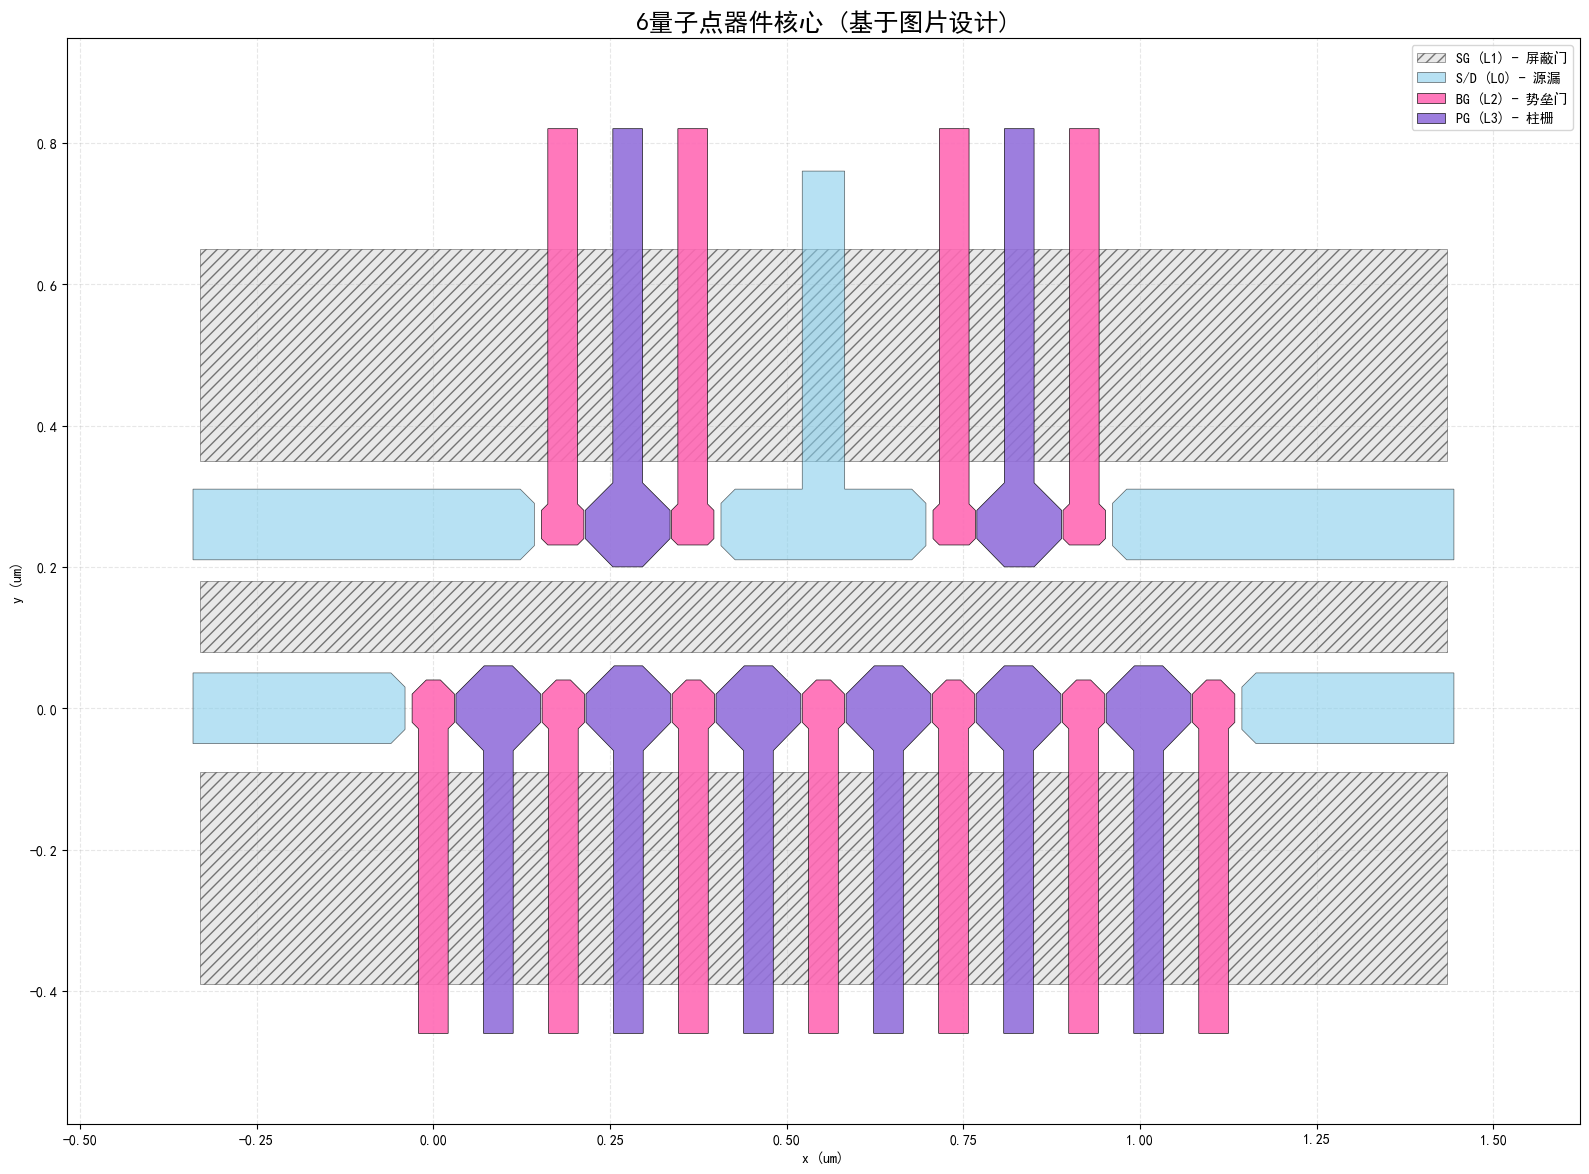


保存GDS文件...
GDS已保存: ./output_6dot\6qd_device_core.gds


In [5]:
# Read and visualize standard device
import gdstk
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon

output_dir = "./output_6dot"
os.makedirs(output_dir, exist_ok=True)
    
    # 生成6量子点器件核心
print("\n生成6量子点器件核心...")
lib, cell, points = create_6qd_device_core(
    num_dots=6,
    pg_max_width=0.120,
    pg_vert_side_len=0.040,
    pg_chamfer_h=0.040,
    bg_max_width=0.060,
    bg_vert_side_len=0.040,

    gap_pg_bg=0.002,

    d1_gap=0.020,
    d2_gap=0.020,
    
    sg_mid_thick=0.100,
    sg_top_thick=0.300,
    sg_bot_thick=0.300,
    sg_extension=0.300,
    
    lead_width=0.042,
    lead_length_bot=0.4,
    lead_length_top=0.5
)
    
# 可视化
print("\n可视化布局...")
plot_gds(cell, title="6量子点器件核心 (基于图片设计)")
    
# 保存GDS
print("\n保存GDS文件...")
save_gds(lib, os.path.join(output_dir, "6qd_device_core.gds"))

